# Program 4 - LSTM (Long Short-Term Memory) Implementation
This notebook demonstrates a complete LSTM implementation using PyTorch for time series prediction.

In [1]:
# Cell 1: Install and Import Libraries
# Uncomment the line below if you need to install PyTorch
# !pip install torch numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'NumPy version: {np.__version__}')

PyTorch version: 2.10.0+cpu
NumPy version: 2.4.6


In [2]:
# Cell 2: Set Random Seeds for Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


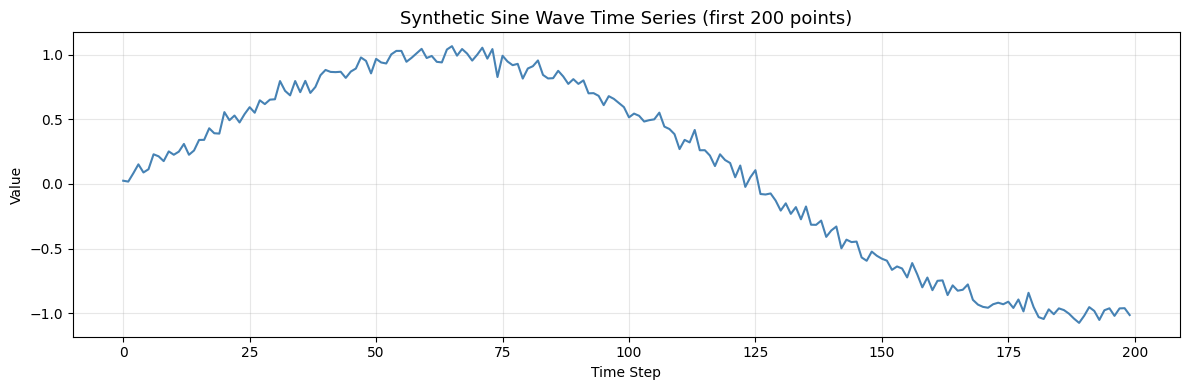

Total data points: 1000


In [3]:
# Cell 3: Generate Synthetic Time Series Data (Sine Wave)
def generate_sine_data(n_samples=1000, noise=0.05):
    t = np.linspace(0, 8 * np.pi, n_samples)
    data = np.sin(t) + noise * np.random.randn(n_samples)
    return data

# Generate and visualize data
raw_data = generate_sine_data()

plt.figure(figsize=(12, 4))
plt.plot(raw_data[:200], color='steelblue', linewidth=1.5)
plt.title('Synthetic Sine Wave Time Series (first 200 points)', fontsize=13)
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Total data points: {len(raw_data)}')

In [4]:
# Cell 4: Preprocess Data - Normalization and Sequence Creation
def create_sequences(data, seq_length):
    """Create input-output pairs from time series data."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Normalize data
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(raw_data.reshape(-1, 1)).flatten()

# Hyperparameters
SEQ_LENGTH = 30       # Number of time steps to look back
BATCH_SIZE = 32
TEST_SPLIT = 0.2

# Create sequences
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SPLIT, shuffle=False)

print(f'Training sequences: {X_train.shape}')
print(f'Test sequences:     {X_test.shape}')

Training sequences: (776, 30)
Test sequences:     (194, 30)


In [5]:
# Cell 5: Convert Data to PyTorch Tensors and Create DataLoaders
X_train_t = torch.FloatTensor(X_train).unsqueeze(-1).to(device)  # (N, seq_len, 1)
y_train_t = torch.FloatTensor(y_train).unsqueeze(-1).to(device)  # (N, 1)
X_test_t  = torch.FloatTensor(X_test).unsqueeze(-1).to(device)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(-1).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test  batches: {len(test_loader)}')
print(f'Input shape per batch: (batch, {SEQ_LENGTH}, 1)')

Train batches: 25
Test  batches: 7
Input shape per batch: (batch, 30, 1)


In [6]:
# Cell 6: Define the LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Fully connected output layer
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))  # out: (batch, seq_len, hidden_size)

        # Take last time step output
        out = self.fc(out[:, -1, :])  # (batch, output_size)
        return out

# Instantiate model
model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2)
model = model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 52,545


In [8]:
# Cell 7: Define Loss Function, Optimizer and LR Scheduler
LEARNING_RATE = 0.001
EPOCHS = 50

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=5,
    factor=0.5
)

print(f'Criterion : {criterion}')
print(f'Optimizer : {optimizer.__class__.__name__}')
print(f'Epochs    : {EPOCHS}')
print(f'LR        : {LEARNING_RATE}')

Criterion : MSELoss()
Optimizer : Adam
Epochs    : 50
LR        : 0.001


In [9]:
# Cell 8: Training Loop
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

# Train the model
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss   = evaluate(model, test_loader, criterion)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{EPOCHS}]  Train Loss: {train_loss:.6f}  Val Loss: {val_loss:.6f}')

print('\nTraining complete!')

Epoch [  1/50]  Train Loss: 0.345347  Val Loss: 0.072759
Epoch [ 10/50]  Train Loss: 0.003815  Val Loss: 0.003562
Epoch [ 20/50]  Train Loss: 0.004606  Val Loss: 0.003118
Epoch [ 30/50]  Train Loss: 0.003200  Val Loss: 0.002388
Epoch [ 40/50]  Train Loss: 0.003136  Val Loss: 0.003368
Epoch [ 50/50]  Train Loss: 0.002956  Val Loss: 0.002323

Training complete!


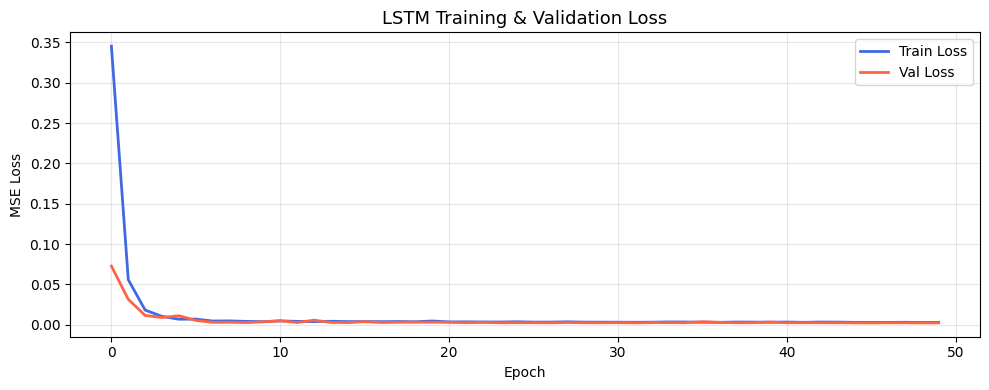

In [10]:
# Cell 9: Plot Training and Validation Loss Curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='royalblue', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   color='tomato',    linewidth=2)
plt.title('LSTM Training & Validation Loss', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Cell 10: Make Predictions on Test Set
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(y_batch.cpu().numpy().flatten())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

# Inverse transform to original scale
preds_inv   = scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
targets_inv = scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

print(f'Predictions shape : {preds_inv.shape}')
print(f'First 5 predicted : {preds_inv[:5].round(4)}')
print(f'First 5 actual    : {targets_inv[:5].round(4)}')

Predictions shape : (194,)
First 5 predicted : [0.9675 0.9695 0.9702 0.9744 0.9755]
First 5 actual    : [1.0009 0.9691 1.0585 0.953  0.9898]


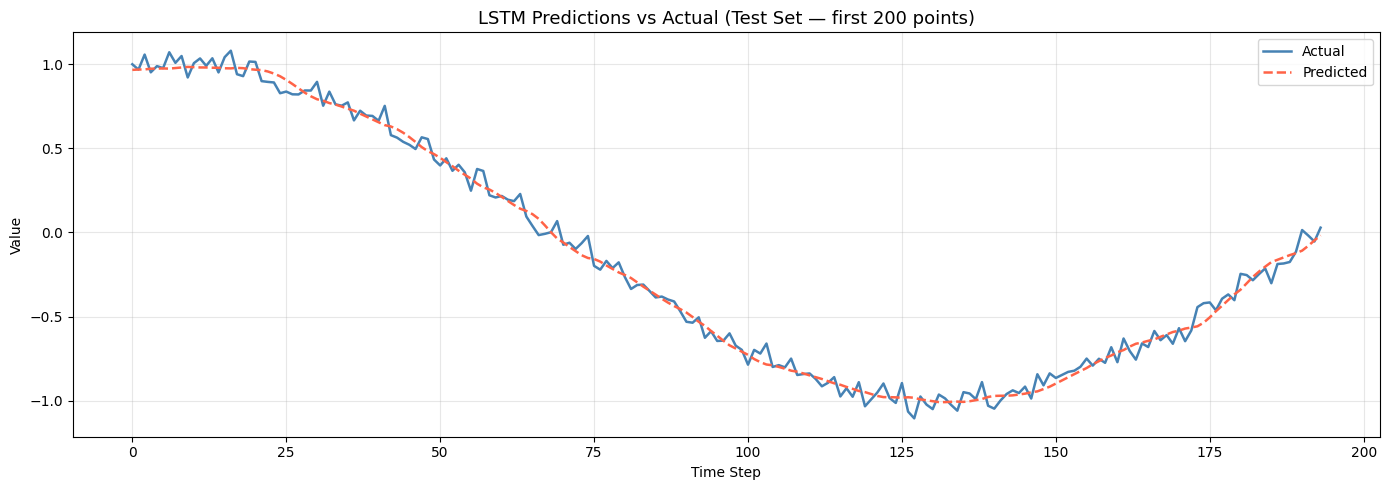

In [12]:
# Cell 11: Plot Predictions vs Actual Values
plt.figure(figsize=(14, 5))
plt.plot(targets_inv[:200], label='Actual',    color='steelblue', linewidth=1.8)
plt.plot(preds_inv[:200],   label='Predicted', color='tomato',    linewidth=1.8, linestyle='--')
plt.title('LSTM Predictions vs Actual (Test Set — first 200 points)', fontsize=13)
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Cell 12: Evaluate Model with Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(targets_inv, preds_inv)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(targets_inv, preds_inv)
r2   = r2_score(targets_inv, preds_inv)

print('=' * 40)
print('         Model Evaluation Metrics')
print('=' * 40)
print(f'  MSE  : {mse:.6f}')
print(f'  RMSE : {rmse:.6f}')
print(f'  MAE  : {mae:.6f}')
print(f'  R²   : {r2:.6f}')
print('=' * 40)

         Model Evaluation Metrics
  MSE  : 0.002835
  RMSE : 0.053240
  MAE  : 0.042938
  R²   : 0.994195


In [14]:
# Cell 13: Save and Load the Model
# Save model weights
torch.save(model.state_dict(), 'lstm_model.pth')
print('Model saved to lstm_model.pth')

# Load model
loaded_model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2)
loaded_model.load_state_dict(torch.load('lstm_model.pth', map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()
print('Model loaded successfully!')

Model saved to lstm_model.pth
Model loaded successfully!


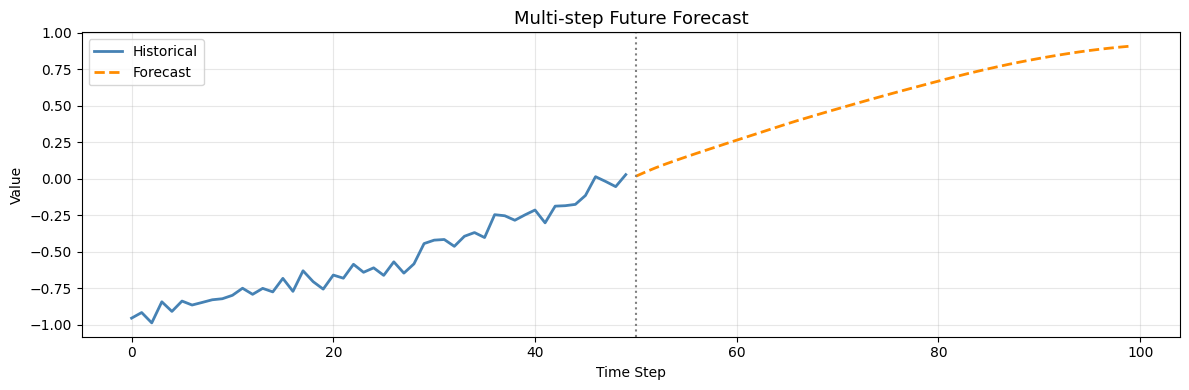

Future predictions (first 10): [0.0173 0.0481 0.0766 0.1026 0.1271 0.1508 0.1742 0.1971 0.2197 0.2425]


In [15]:
# Cell 14: Inference — Predict Next N Steps (Multi-step Forecasting)
def forecast_future(model, last_sequence, n_steps, scaler):
    """Autoregressively predict n_steps into the future."""
    model.eval()
    seq = list(last_sequence.copy())
    predictions = []
    with torch.no_grad():
        for _ in range(n_steps):
            input_tensor = torch.FloatTensor(seq[-SEQ_LENGTH:]).unsqueeze(0).unsqueeze(-1).to(device)
            pred = model(input_tensor).item()
            seq.append(pred)
            predictions.append(pred)
    # Inverse transform
    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Use the last known sequence to forecast 50 steps ahead
last_seq     = data_scaled[-SEQ_LENGTH:]
future_preds = forecast_future(model, last_seq, n_steps=50, scaler=scaler)

plt.figure(figsize=(12, 4))
plt.plot(range(50), raw_data[-50:], label='Historical',  color='steelblue', linewidth=2)
plt.plot(range(50, 100), future_preds, label='Forecast', color='darkorange', linewidth=2, linestyle='--')
plt.axvline(x=50, color='gray', linestyle=':', linewidth=1.5)
plt.title('Multi-step Future Forecast', fontsize=13)
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Future predictions (first 10):', future_preds[:10].round(4))